In [1]:
!pip install biopython #install Biopython
import Bio
print(Bio.__version__) #prints current Biopython version
from Bio import SeqIO
from Bio.Data import CodonTable
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
1.87


In [2]:
## 1 ##

!wget https://raw.githubusercontent.com/kpetersen5/Petersen_EEOB5460_Spring2026/refs/heads/main/penguins_cytb.fasta
# used !wget to pull penguins_cytb.fasta from GitHub repository 
fasta_fn = "penguins_cytb.fasta" #defined fasta_fn to run the code block

def get_sequences_from_file(fasta_fn):
    """
    Description: Creates a for loop to parse a Fasta file and extract the 2-part species 
    name and its corresponding DNA sequence. This data is added to a dictionary as a 
    key-value pair
    
    Argument: fasta file (fasta_fn) which is a string
    
    Output: A dictionary that is composed of the species name, the key and the 
    corresponding DNA sequence, the value. 
    """
    sequence_data_dict = {}
    for record in SeqIO.parse(fasta_fn, "fasta"):
        description = record.description.split() #split header (denoted by >) into list of strings 
        species_name = description[1] + " " + description[2] #concates species name using element 2&3 of header
        sequence_data_dict[species_name] = record.seq #assigns key-value pair for dictionary key = species name, value = DNA sequence
    return(sequence_data_dict) #exits the function and returns values to caller

pen_seq_dict = get_sequences_from_file(fasta_fn) #Calls the function to be ran
print(pen_seq_dict) #Prints the raw dictonary i.e the species name and nucleotide sequence
pen_seq_dict_str = {species: str(sequence) for species, sequence in pen_seq_dict.items()} #Converting Seq objects to string to visualize the DataFrame
pen_seq_dict_df = pd.DataFrame.from_dict(pen_seq_dict_str, orient='index', columns=['Nucleotide Sequence']) #DataFrame creation
pen_seq_dict_df #prints the DataFrame

--2026-05-03 11:45:25--  https://raw.githubusercontent.com/kpetersen5/Petersen_EEOB5460_Spring2026/refs/heads/main/penguins_cytb.fasta
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14931 (15K) [text/plain]
Saving to: ‘penguins_cytb.fasta.24’

penguins_cytb.fasta 100%[===================>]  14.58K  --.-KB/s    in 0.001s  

2026-05-03 11:45:25 (12.7 MB/s) - ‘penguins_cytb.fasta.24’ saved [14931/14931]

{'Aptenodytes forsteri': Seq('ATGGCCCCAAATCTCCGAAAATCCCATCCCCTCCTAAAAATAATTAATAACTCC...TAA'), 'Aptenodytes patagonicus': Seq('ATGGCCCCAAACCTCCGAAAATCCCATCCTCTCCTAAAAATAATTAATAACTCC...TAA'), 'Eudyptes chrysocome': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'), 'Eudyptes chrysolophus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAA

,Nucleotide Sequence
Aptenodytes forsteri,ATGGCCCCAAATCTCCGAAAATCCCATCCCCTCCTAAAAATAATTA...
Aptenodytes patagonicus,ATGGCCCCAAACCTCCGAAAATCCCATCCTCTCCTAAAAATAATTA...
Eudyptes chrysocome,ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCA...
Eudyptes chrysolophus,ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCA...
Eudyptes sclateri,ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCA...
Eudyptula minor,ATGGCCCCCAACCTCCGAAAATCTCACCCCCTCCTAAAAATAATCA...
Pygoscelis adeliae,ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATTA...
Pygoscelis antarctica,ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATCA...
Pygoscelis papua,ATGGCCCCCAACCTTCGAAAATCCCACCCTCTCCTAAAAATAATCA...
Spheniscus demersus,ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAACAATCA...


In [3]:
## 2 ##
def translate_function_loop(pen_seq_dict): #creates function
    """
    Description: Translates DNA sequences to protein sequences using a manual for loop.
    
    Argument: pen_seq_dict: This is a dictonary where the keys are the penguin species names (str)
              and the values are the penguin DNA sequence (bio.seq)
    
    Output: aa_seq_loop_dict: This is a dictionary where the keys are the penguin species names (str)
            and the values are the penguin protein sequence (bio.seq)
    """
    mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"] #defines what codon table to use
    aa_seq_loop_dict = {} #initalizes an empty dictionary that will store the species name and protein sequence
    for species, sequence in pen_seq_dict.items(): #for loop that iterates over each species:sequence pair in the pen_seq_dict from above
        aa_seq_loop = "" #initalizes the string for the amino acid sequence for each species 
        for nuc in range(0, len(sequence), 3): #for loop that iterates over all the nucleotides in the sequence. It starts with the first codon (position 0), ends with the sequence lenght, and uses a step of 3 codons
            codon = sequence[nuc : nuc + 3] #defines the codon. This will take three letters at a time and feed it into mito_table.forward_table[codon] line below
            if codon in mito_table.stop_codons: #If a stop condon is encountered in the sequence, the translation process will stop (i.e break)
                break 
            aa = mito_table.forward_table[codon] #translates the 3-letter nucleotide sequence defined as a condon in an amino acid
            aa_seq_loop += aa #adds each consecutive amino acid that is translated to the growing amino acid string
        aa_seq_loop_dict[species] = aa_seq_loop #Creates the amino acid sequence dictionary. The species is the key and the amino acid sequecne is the value 
    return(aa_seq_loop_dict) #exits the function and returns values to caller

pen_aa_seq_loop_dict = translate_function_loop(pen_seq_dict) #calls the function to be ran
pen_aa_seq_loop_dict_df = pd.DataFrame.from_dict(pen_aa_seq_loop_dict, orient='index', columns=['Protein Sequence']) #creates a DataFrame
pen_aa_seq_loop_dict_df #Prints DataFrame (better visual than printing the entire aa string) 



,Protein Sequence
Aptenodytes forsteri,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Aptenodytes patagonicus,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Eudyptes chrysocome,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...
Eudyptes chrysolophus,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...
Eudyptes sclateri,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...
Eudyptula minor,MAPNLRKSHPLLKMINNSLIDLPTPSNISTWWNFGSLLGICLITQI...
Pygoscelis adeliae,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Pygoscelis antarctica,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Pygoscelis papua,MAPNLRKSHPLLKMINKSLIDLPTPPNISAWWNFGSLLGICLITQI...
Spheniscus demersus,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...


In [4]:
## 3 ##
# Yes there is a better way to translate a nucleotide sequence. Biopython has a built in translate tool 

def translate_function_Bp(pen_seq_dict): #creates function
    """
    Description: Translates DNA sequences to protein sequences using Biopython build-in translate function.
    
    Argument: pen_seq_dict: This is a dictonary where the keys are the penguin species names (str) 
    and the values are the penguin DNA sequence (bio.seq)
    
    Output: aa_seq_Bp_dict: This is a dictionary where the keys are the penguin species names (str) 
    and the values are the penguin protein sequence (bio.seq)
    """
    aa_seq_Bp_dict = {} #initalizes an empty dictionary that will store the species name and protein sequence
    for species, sequence in pen_seq_dict.items(): #for loop that iterates over each species:sequence pair in the pen_seq_dict from above
        aa_seq_Bp_dict[species] = str(sequence.translate(table="Vertebrate Mitochondrial", to_stop=True)) #Uses the built in translation tool, defines what codon table to use. Using the to_stop=True stops the translation at the first stop codon
    return (aa_seq_Bp_dict) #exits the function and returns values to caller

pen_aa_seq_Bp_dict = translate_function_Bp(pen_seq_dict) #calls the function to be ran
pen_aa_seq_Bp_dict_df = pd.DataFrame.from_dict(pen_aa_seq_Bp_dict, orient='index', columns=['Protein Sequence']) #creates a DataFrame
pen_aa_seq_Bp_dict_df #Prints DataFrame (better visual than printing the entire aa string) 

,Protein Sequence
Aptenodytes forsteri,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Aptenodytes patagonicus,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Eudyptes chrysocome,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...
Eudyptes chrysolophus,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...
Eudyptes sclateri,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...
Eudyptula minor,MAPNLRKSHPLLKMINNSLIDLPTPSNISTWWNFGSLLGICLITQI...
Pygoscelis adeliae,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Pygoscelis antarctica,MAPNLRKSHPLLKMINNSLIDLPTPSNISAWWNFGSLLGICLTTQI...
Pygoscelis papua,MAPNLRKSHPLLKMINKSLIDLPTPPNISAWWNFGSLLGICLITQI...
Spheniscus demersus,MAPNLRKSHPLLKTINNSLIDLPTPSNISAWWNFGSLLGICLATQI...


In [5]:
## 4 ##

from Bio.SeqUtils.ProtParam import ProteinAnalysis

def aa_MW_calc(aa_str): #creates function 
    """
    Description: Calculates the molecular weight of the protein sequence using Biopython build-in molecular weight calculator function.
    
    Argument: aa_str: This is a dictonary where the keys are the penguin species names (str)
              and the values are the penguin protein sequence (bio.seq)
    
    Output: MW: This is a dictionary where the keys are the penguin species names (str)
            and the values are the molcular weight of the penguin protein sequence (bio.seq)
    """
    MW = {} #initalizes an empty dictionary that will store the species name and molecular weight
    for species, sequence in aa_str.items(): #for loop that iterates over each species:sequence pair in the aa_str defined below
        analysed_seq = ProteinAnalysis(sequence) #initializes the calculation for MW of the protein sequence
        MW[species]=analysed_seq.molecular_weight() #Addes the species name and calculated MW key-value pair to the MW dictionary one entry at a time 
    return (MW) #exits the function and returns values to caller

aa_str = {species: str(sequence) for species, sequence in pen_aa_seq_Bp_dict.items()} #Converting Seq objects to string as an argument to pass through ProteinAnalysis function
pen_aa_MW = aa_MW_calc(aa_str) #calls the function to be ran
pen_aa_MW_df = pd.DataFrame.from_dict(pen_aa_MW, orient='index', columns=['Molecular Weight (Da)']) #creates a DataFrame
pen_aa_MW_df #prints DataFrame


,Molecular Weight (Da)
Aptenodytes forsteri,42459.6021
Aptenodytes patagonicus,42563.7067
Eudyptes chrysocome,42475.5753
Eudyptes chrysolophus,42445.5493
Eudyptes sclateri,42475.5753
Eudyptula minor,42491.6408
Pygoscelis adeliae,42458.6140
Pygoscelis antarctica,42404.5423
Pygoscelis papua,42595.8759
Spheniscus demersus,42431.5490


In [6]:
## 5 ##
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction #This is a built in GC calculator in Biopython. Syntax can be found in Biopython Turorial & Cookbook (https://biopython.org/docs/dev/Tutorial/chapter_seq_objects.html)

def GC_calc(str_GC): #creates function 
    """
    Description: Calculates the GC content of the DNA sequence using Biopython build-in GC content calculator function.
    
    Argument: GC_str: This is a dictonary where the keys are the penguin species names (str)
              and the values are the penguin DNA sequence (bio.seq)
    
    Output: GC: This is a dictionary where the keys are the penguin species names (str)
            and the values are the GC content percet of the penguin DNA sequence (bio.seq)
    """
    GC = {} #initalizes an empty dictionary that will store the species name and GC-content %
    for species, sequence in str_GC.items(): #for loop that iterates over each species:sequence pair in the str_GC defined below
        GC[species]=gc_fraction(sequence) #Addes the species name and calculated GC-content % key-value pair to the GC dictionary one entry at a time 
    return (GC) #exits the function and returns values to caller

str_GC = {species: str(sequence) for species, sequence in pen_seq_dict.items()} #Converting Seq objects to string as an argument to pass through gc_fraction function
pen_GC = GC_calc(str_GC) #calls the function to be ran
pen_GC_df = pd.DataFrame.from_dict(pen_GC, orient='index', columns=['GC Content (%)']) #creates a DataFrame
pen_GC_df #prints DataFrame


,GC Content (%)
Aptenodytes forsteri,0.483815
Aptenodytes patagonicus,0.496938
Eudyptes chrysocome,0.511811
Eudyptes chrysolophus,0.509186
Eudyptes sclateri,0.508311
Eudyptula minor,0.492563
Pygoscelis adeliae,0.490814
Pygoscelis antarctica,0.477690
Pygoscelis papua,0.471566
Spheniscus demersus,0.482940


In [7]:
import pandas as pd
import numpy as np

!wget https://raw.githubusercontent.com/kpetersen5/Petersen_EEOB5460_Spring2026/main/penguins_mass.csv

cytb_seqs = get_sequences_from_file("penguins_cytb.fasta") 

penguins_df = pd.read_csv("penguins_mass.csv") # Includes only data for body mass 
species_list = list(penguins_df.species)
penguins_df

--2026-05-03 11:45:25--  https://raw.githubusercontent.com/kpetersen5/Petersen_EEOB5460_Spring2026/main/penguins_mass.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 306 [text/plain]
Saving to: ‘penguins_mass.csv.17’

penguins_mass.csv.1 100%[===================>]     306  --.-KB/s    in 0s      

2026-05-03 11:45:25 (6.64 MB/s) - ‘penguins_mass.csv.17’ saved [306/306]



,species,mass
0,Aptenodytes forsteri,28.00
1,Aptenodytes patagonicus,13.40
2,Eudyptes chrysocome,2.80
3,Eudyptes chrysolophus,4.50
4,Eudyptes sclateri,4.25
5,Eudyptula minor,1.60
6,Pygoscelis adeliae,4.60
7,Pygoscelis antarctica,4.10
8,Pygoscelis papua,6.10
9,Spheniscus demersus,3.20


In [8]:
### 6 ###

penguins_df["Molecular Weight (Da)"] = np.nan #creates the MW column]
penguins_df["GC Content (%)"] = np.nan #creates the GC column
#I tried using .fillna() but it kept throwing errors so I used the Numpy not a number command 
penguins_df


,species,mass,Molecular Weight (Da),GC Content (%)
0,Aptenodytes forsteri,28.00,NaN,NaN
1,Aptenodytes patagonicus,13.40,NaN,NaN
2,Eudyptes chrysocome,2.80,NaN,NaN
3,Eudyptes chrysolophus,4.50,NaN,NaN
4,Eudyptes sclateri,4.25,NaN,NaN
5,Eudyptula minor,1.60,NaN,NaN
6,Pygoscelis adeliae,4.60,NaN,NaN
7,Pygoscelis antarctica,4.10,NaN,NaN
8,Pygoscelis papua,6.10,NaN,NaN
9,Spheniscus demersus,3.20,NaN,NaN


In [9]:
### 7 ###

for species, sequence in cytb_seqs.items(): # Loops across all the cytb sequences, one species at a time
    translate_aa_dict = translate_function_Bp({species:sequence}) # Biopython translation function I wrote earlier to translate the DNA sequence
    aa_seq = translate_aa_dict[species] # Takes the dictonary that was created and just grab the strings of sequences that were translated in the previous step to use for MW and GC calculations
    
    analysed_aa_seq = ProteinAnalysis(str(aa_seq)) # Initializes the sequence strings to be ready for MW and GC calculations
    
    MW_V2 = analysed_aa_seq.molecular_weight() # Calcualtes the MW of the protein sequence 
    gc_V2 = gc_fraction(sequence) # Calculates the GC content using the original DNA sequence
    
    penguins_df.loc[penguins_df['species'] == species, 'Molecular Weight (Da)'] = MW_V2 # Using the penguins dataframe created above this finds the rows with matching penguin species and addes the corresponding MW that was just calculated
    penguins_df.loc[penguins_df['species'] == species, 'GC Content (%)'] = gc_V2 # Using the penguins dataframe created above this finds the rows with matching penguin species and addes the corresponding GC content that was just calculated

penguins_df # Prints the dataframe


,species,mass,Molecular Weight (Da),GC Content (%)
0,Aptenodytes forsteri,28.00,42459.6021,0.483815
1,Aptenodytes patagonicus,13.40,42563.7067,0.496938
2,Eudyptes chrysocome,2.80,42475.5753,0.511811
3,Eudyptes chrysolophus,4.50,42445.5493,0.509186
4,Eudyptes sclateri,4.25,42475.5753,0.508311
5,Eudyptula minor,1.60,42491.6408,0.492563
6,Pygoscelis adeliae,4.60,42458.6140,0.490814
7,Pygoscelis antarctica,4.10,42404.5423,0.477690
8,Pygoscelis papua,6.10,42595.8759,0.471566
9,Spheniscus demersus,3.20,42431.5490,0.482940


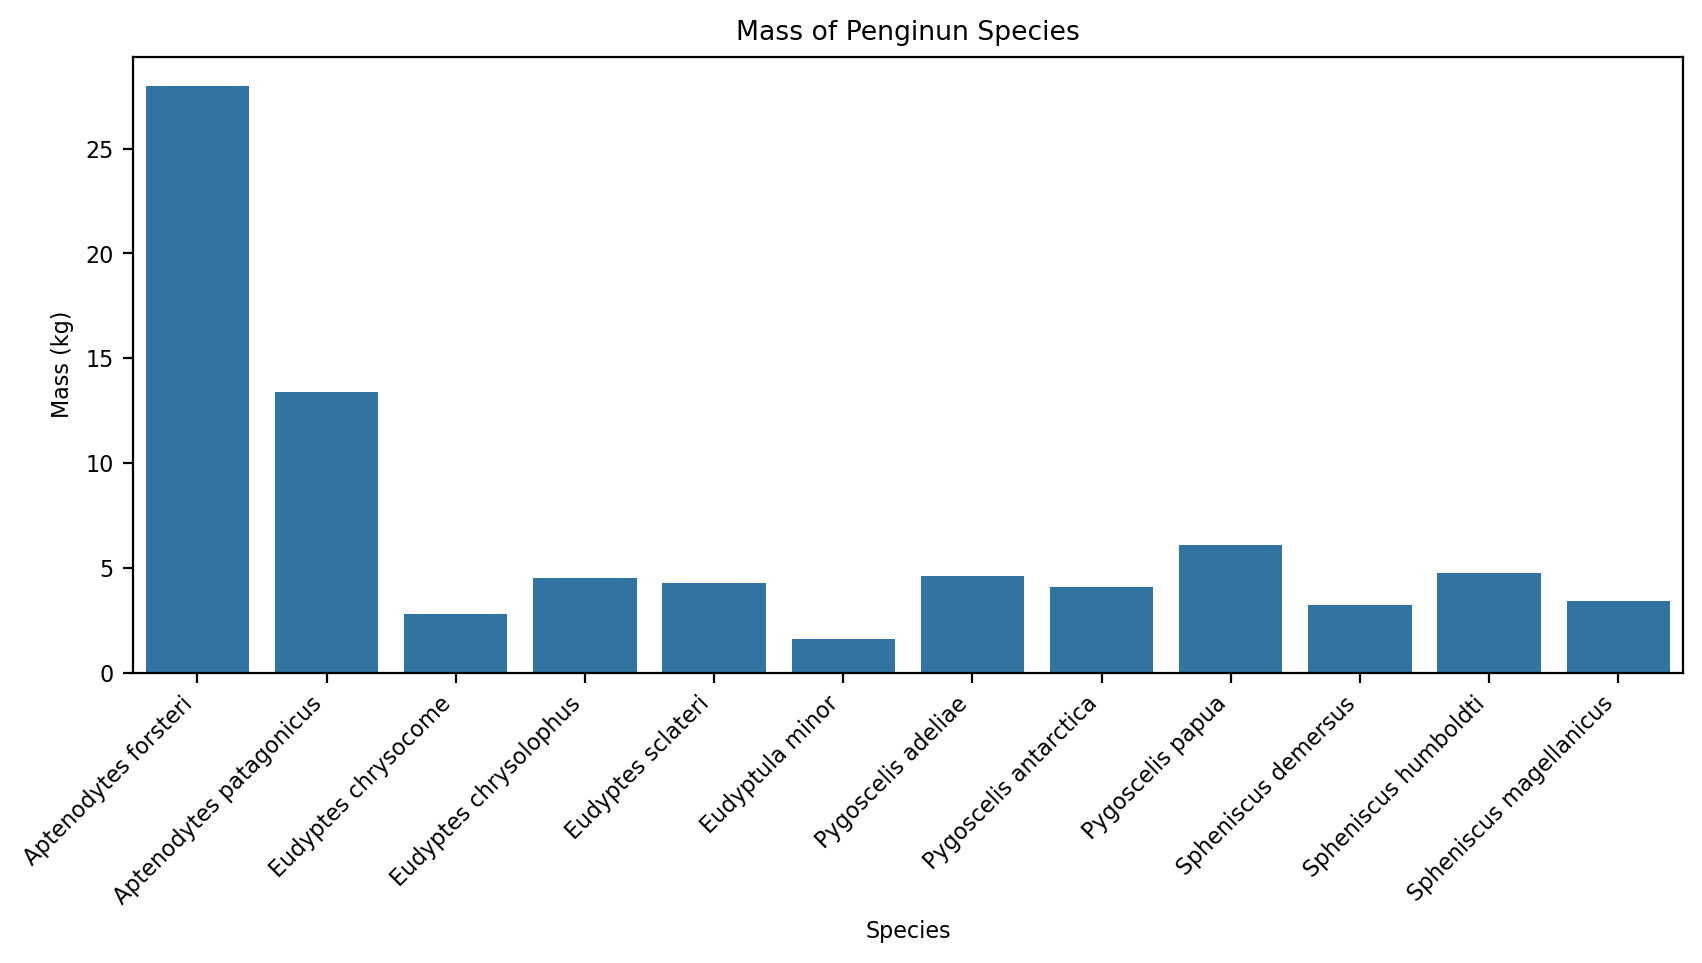

In [10]:
### 8 ###

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10,4
plt.rcParams.update({'font.size': 8})

sns.barplot(data=penguins_df, x="species", y="mass") # Plots the barplot to represent Mass of penguin species
plt.xlabel('Species')
plt.ylabel('Mass (kg)')
plt.title("Mass of Penginun Species")
plt.xticks(rotation=45, ha='right') # Rotates the x-axis labels so they are legible 

plt.show()

# Q1 : The smallest penguin species is Eudyptula minor
# Q2 : According to the Louisville Zoo they live year round in the southern hemisphere, primarily in Australia,
#      but can also be found in Tasmania, New Zealand, and Chile.   

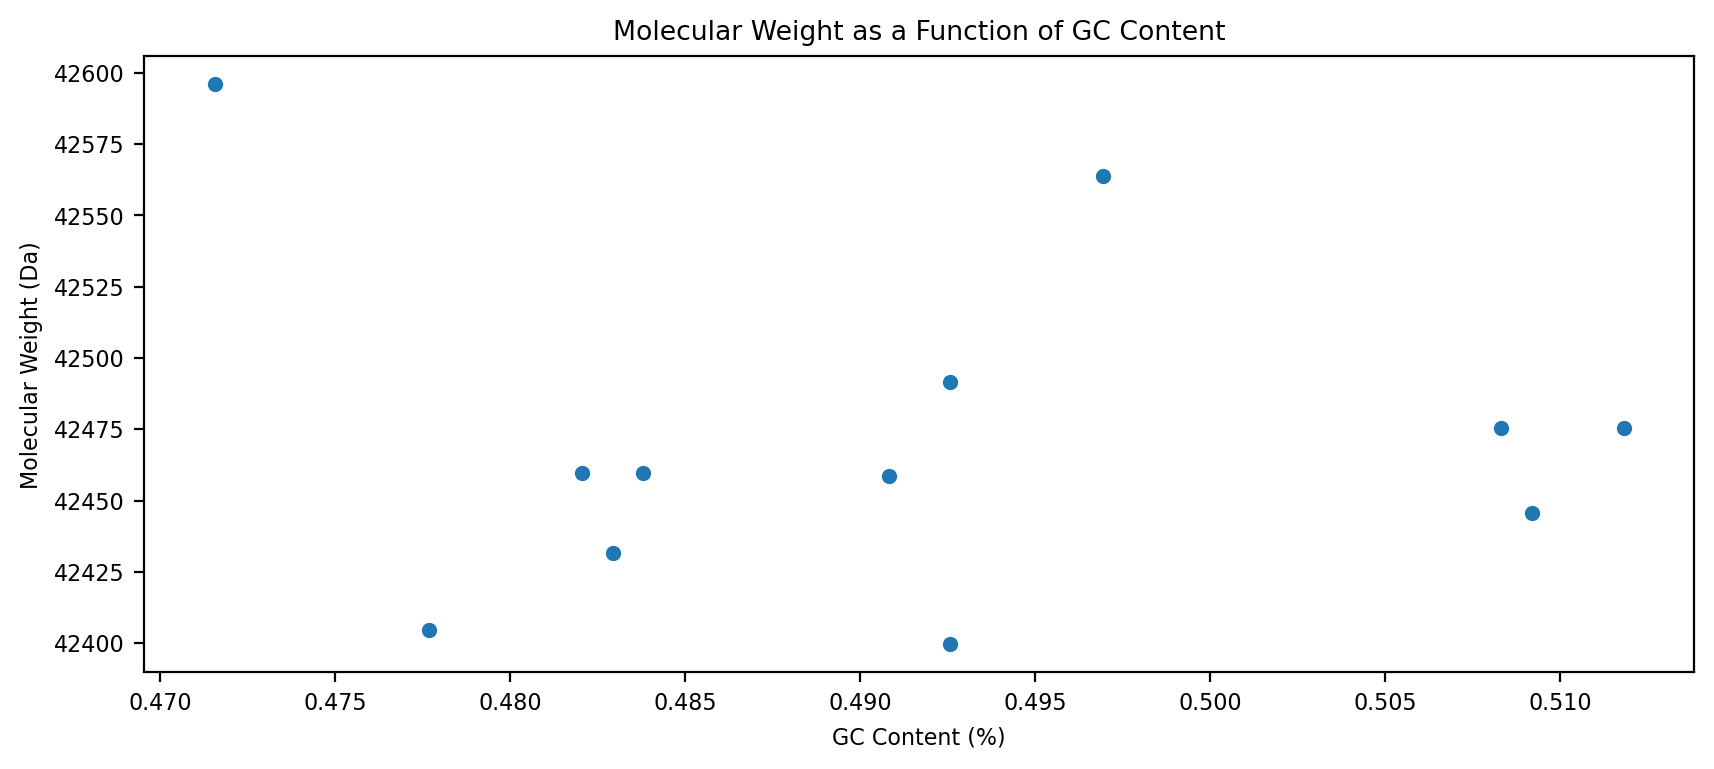

In [11]:
### 9 ###

sns.scatterplot(data=penguins_df, x="GC Content (%)", y="Molecular Weight (Da)") # Creates the GC content vs MW scatter plot
plt.xlabel('GC Content (%)')
plt.ylabel('Molecular Weight (Da)')
plt.title("Molecular Weight as a Function of GC Content")

plt.show()

In [12]:
### 10 ###

penguins_df.to_csv("penguins_mass_cytb.csv", index=False)

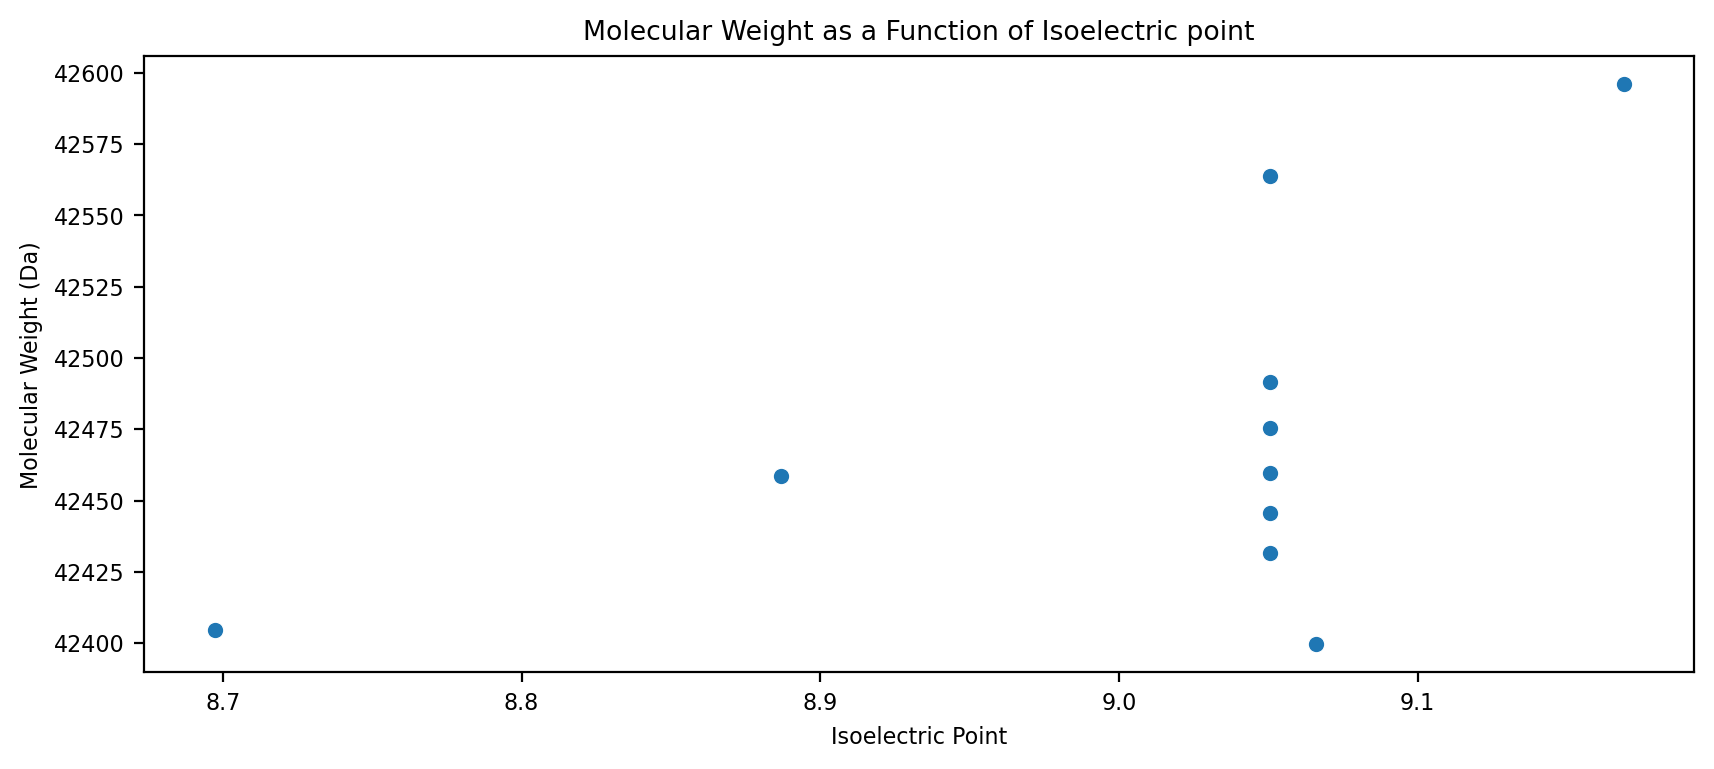

In [13]:
### 11 - BONUS ###

from Bio.SeqUtils.ProtParam import ProteinAnalysis

for species, sequence in cytb_seqs.items(): # Loops across all the cytb sequences, one species at a time
    translate_aa = translate_function_Bp({species:sequence}) # Biopython translation function I wrote earlier to translate the DNA sequence
    aa_str = translate_aa[species] # Takes the dictonary that was created and just grabs the string of sequences that were translated in the previous step to use for MW and pI calculations
    
    analysed_aa_seq = ProteinAnalysis(aa_str) # Initializes the sequence strings to be ready for MW and pI calculations
    
    pI_value = analysed_aa_seq.isoelectric_point() # Calcualtes the pI of the protein sequence 
    MW_value = analysed_aa_seq.molecular_weight() # Calcualtes the MW of the protein sequence 
    
    penguins_df.loc[penguins_df['species'] == species, 'Molecular Weight (Da)'] = MW_value # Using the penguins dataframe created above this finds the rows with matching penguin species and addes the corresponding MW that was just calculated
    penguins_df.loc[penguins_df['species'] == species, 'pI'] = pI_value # Using the penguins dataframe created above this finds the rows with matching penguin species and addes the corresponding pI that was just calculated


sns.scatterplot(data=penguins_df, x="pI", y="Molecular Weight (Da)") # Creates the pI content vs MW scatter plot
plt.xlabel('Isoelectric Point')
plt.ylabel('Molecular Weight (Da)')
plt.title("Molecular Weight as a Function of Isoelectric point")

plt.show()

# This is 2-D gel electrophoresis representation, where proteins are separated by isoelectric point and molecular weight